In [1]:
import polars as pl
import os
import numpy as np
import pandas as pd
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim.lr_scheduler as lr_scheduler

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
DATASET_PATH = '/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/dataset/'
OUTPUT_PATH = '/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/'

In [3]:
def get_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    if device.type == "cuda":
        print(f"Current CUDA device: {torch.cuda.current_device()}")
        print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

    return device

In [4]:
device = get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla V100-PCIE-16GB


In [5]:
# Define file numbering based on the index
def format_file_number(number):
    if number < 10:
        return f"00{number}"
    elif number < 100:
        return f"0{number}"
    else:
        return str(number)

In [6]:
# Custom dataset class
class HepG2Dataset(Dataset):
    def __init__(self, total_samples, features, indexes):
        self.total_samples = total_samples
        self.features = features
        self.indexes = indexes

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        r1 = random.choice(self.indexes)
        r2 = random.choice(self.indexes)
        
        feature_1 = self.features[r1, 1]
        feature_2 = self.features[r2, 1]
        feature = np.concatenate((feature_1, feature_2), axis=0)
        
        val_1 = self.features[r1, 2]
        val_2 = self.features[r2, 2]
        
        y = 1 if val_1 > val_2 else 0
        
        return feature, y

In [7]:
# Binary Classifier class
class BinaryClassifierDropOutL1L2(nn.Module):
    def __init__(self, input_size, hidden1_size=64, hidden2_size=32, output_size=1, dropout_rate=0.2, l1_lambda=0.001, l2_lambda=0.001):
        super(BinaryClassifierDropOutL1L2, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1_size),
            # nn.ReLU(),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden1_size, hidden2_size),
            # nn.ReLU(),
            nn.LeakyReLU(0.1),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden2_size, output_size),
            nn.Sigmoid()
        )

        self.l1_lambda = l1_lambda
        self.l2_lambda = l2_lambda

    def forward(self, x):
        # x = x.squeeze(1)
        outputs = self.network(x)
        l1_reg = torch.tensor(0., requires_grad=True)
        l2_reg = torch.tensor(0., requires_grad=True)

        for name, param in self.named_parameters():
            if 'weight' in name:
                l1_reg = l1_reg + torch.linalg.norm(param, 1)
                l2_reg = l2_reg + torch.linalg.norm(param, 2)

        return outputs, self.l1_lambda * l1_reg, self.l2_lambda * l2_reg

    def predict(self, x):
        with torch.no_grad():
            outputs, _, _ = self.forward(x)
            return (outputs >= 0.5).long()

In [8]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, item_name, num_items, file_name):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss {item_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(0.4, 0.8)
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy {item_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.ylim(50, 90)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    plt.savefig(file_name)
    
    plt.show()

In [9]:
# Load histone data
data_df = pl.read_parquet(os.path.join(DATASET_PATH, 'HepG2_exp_histones.parquet'))
data_df

gene_id,H3K9ac,H3K9ac_wc,H3K9ac_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K27ac,H3K27ac_wc,H3K27ac_len,H3K27me3,H3K27me3_wc,H3K27me3_len,value_1,value_2
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0
"""XLOC_000006""","[0.0, 0.0, … 0.0]",33,100,"[0.0, 0.0, … 0.0]",46,100,"[0.0, 0.0, … 0.0]",23,100,"[0.0, 0.0, … 0.0]",4,100,"[5.37483, 5.37483, … 5.37483]",100,100,0.0888452,0.136965
"""XLOC_000007""","[0.0, 0.0, … 0.0]",33,100,"[0.0, 0.0, … 0.0]",46,100,"[0.0, 0.0, … 0.0]",23,100,"[0.0, 0.0, … 0.0]",4,100,"[5.37483, 5.37483, … 5.37483]",100,100,4.04743,4.16567
"""XLOC_000008""","[0.0, 0.0, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",3,100,"[0.0, 0.0, … 0.0]",18,100,"[0.0, 0.0, … 14.6253]",16,100,"[0.0, 0.0, … 0.0]",0,100,26.7934,30.2747
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0


In [10]:
# Load train-val-test index dataset
train_idx = pd.read_parquet(os.path.join(DATASET_PATH, 'train_idx.parquet'))["values"].to_list()
val_idx = pd.read_parquet(os.path.join(DATASET_PATH, 'val_idx.parquet'))["values"].to_list()
test_idx = pd.read_parquet(os.path.join(DATASET_PATH, 'test_idx.parquet'))["values"].to_list()

In [11]:
print(len(train_idx))
print(len(val_idx))
print(len(test_idx))

17723
2215
2215


In [12]:
# Load permutation list
permutation_lst = pl.read_parquet(os.path.join(DATASET_PATH, 'marker_combinations.parquet'))["combination"].to_list()

In [13]:
START = 0
END = 5

In [14]:
working_perm = permutation_lst[START:END]
working_perm

[['H3K4me3'], ['H3K9ac'], ['H3K9me3'], ['H3K27ac'], ['H3K27me3']]

In [15]:
INDEX = 20
item = permutation_lst[INDEX]
print(item)

['H3K4me3', 'H3K27ac', 'H3K27me3']


In [16]:
# Building the dataframe based on histone markers
data_df = data_df.with_columns(histone=pl.concat_list(item))
data_df

gene_id,H3K9ac,H3K9ac_wc,H3K9ac_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K27ac,H3K27ac_wc,H3K27ac_len,H3K27me3,H3K27me3_wc,H3K27me3_len,value_1,value_2,histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,f64,list[f64]
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0,"[0.0, 0.0, … 0.0]"
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0,"[0.0, 0.0, … 0.0]"
"""XLOC_000006""","[0.0, 0.0, … 0.0]",33,100,"[0.0, 0.0, … 0.0]",46,100,"[0.0, 0.0, … 0.0]",23,100,"[0.0, 0.0, … 0.0]",4,100,"[5.37483, 5.37483, … 5.37483]",100,100,0.0888452,0.136965,"[0.0, 0.0, … 5.37483]"
"""XLOC_000007""","[0.0, 0.0, … 0.0]",33,100,"[0.0, 0.0, … 0.0]",46,100,"[0.0, 0.0, … 0.0]",23,100,"[0.0, 0.0, … 0.0]",4,100,"[5.37483, 5.37483, … 5.37483]",100,100,4.04743,4.16567,"[0.0, 0.0, … 5.37483]"
"""XLOC_000008""","[0.0, 0.0, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",3,100,"[0.0, 0.0, … 0.0]",18,100,"[0.0, 0.0, … 14.6253]",16,100,"[0.0, 0.0, … 0.0]",0,100,26.7934,30.2747,"[0.0, 0.0, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0,"[0.0, 0.0, … 0.0]"
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0,"[0.0, 0.0, … 0.0]"
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.0,0.0,"[0.0, 0.0, … 0.0]"


In [17]:
X = data_df["gene_id", "histone", "value_1"]
X

gene_id,histone,value_1
str,list[f64],f64
"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_000006""","[0.0, 0.0, … 5.37483]",0.0888452
"""XLOC_000007""","[0.0, 0.0, … 5.37483]",4.04743
"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…
"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [18]:
len(X['histone'][0].to_list())

300

In [19]:
X_np = X.to_numpy()
X_np

array([['XLOC_000001',
        array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
               0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [20]:
len(X_np[0][1])

300

In [21]:
NUM_ITEMS = 100
BATCH_SIZE = 32
INPUT_SIZE = len(X_np[0][1]) * 2 # Two histone marker data from two gene IDs
NUM_EPOCHS = 100
START_EPOCH = 0
DROPOUT_RATE = 0.3
L1_lambda = 0.005
L2_lambda = 0.001

In [22]:
train_dataset = HepG2Dataset(int(0.8 * NUM_ITEMS), X_np, train_idx)
val_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), X_np, val_idx)
test_dataset = HepG2Dataset(int(0.1 * NUM_ITEMS), X_np, test_idx)

In [23]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

80
10
10


In [24]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [25]:
# Define classifier model
model = BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [26]:
print(model)

BinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=600, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [27]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [28]:
# Prepare dataset based on the permutation
item_name = '-'.join(item)
print(item)
print(item_name)

['H3K4me3', 'H3K27ac', 'H3K27me3']
H3K4me3-H3K27ac-H3K27me3


In [29]:
FILE_NUMBER = format_file_number(INDEX)
FILE_NUMBER

'020'

In [30]:
IMAGE_FILE = os.path.join(OUTPUT_PATH, 'img', 'train', f"{FILE_NUMBER}-{item_name}-ranking.png")
TEST_FILE = os.path.join(OUTPUT_PATH, 'test', f"{FILE_NUMBER}-{item_name}-test-results.txt")
TRAINING_FILE = os.path.join(OUTPUT_PATH, 'train', f"{FILE_NUMBER}-{item_name}-train-validation-metrics.csv")
TEST_RESULT_FILE = os.path.join(OUTPUT_PATH, 'test', f"{FILE_NUMBER}-{item_name}-test-metrics.csv")
ROC_FILE = os.path.join(OUTPUT_PATH, 'img', 'roc', f"{FILE_NUMBER}-{item_name}-roc.png")
CM_FILE = os.path.join(OUTPUT_PATH, 'img', 'cm', f"{FILE_NUMBER}-{item_name}-cm.png")

In [31]:
print(IMAGE_FILE)
print(TEST_FILE)
print(TRAINING_FILE)
print(TEST_RESULT_FILE)
print(ROC_FILE)
print(CM_FILE)

/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/img/train/020-H3K4me3-H3K27ac-H3K27me3-ranking.png
/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/test/020-H3K4me3-H3K27ac-H3K27me3-test-results.txt
/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/train/020-H3K4me3-H3K27ac-H3K27me3-train-validation-metrics.csv
/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/test/020-H3K4me3-H3K27ac-H3K27me3-test-metrics.csv
/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/img/roc/020-H3K4me3-H3K27ac-H3K27me3-roc.png
/group/pmc021/amunif/epi-thesis/workflow/11_HepG2_with_DeepChrome_preprocessing/output/img/cm/020-H3K4me3-H3K27ac-H3K27me3-cm.png


In [32]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:
        outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
        loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')

/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

Epoch [1/100] - [TRAIN] Loss: 0.8765, Accuracy: 47.50%, AUC: 0.50 [VAL] Loss: 0.7392, Accuracy: 50.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [2/100] - [TRAIN] Loss: 0.8313, Accuracy: 55.00%, AUC: 0.50 [VAL] Loss: 0.6608, Accuracy: 70.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [3/100] - [TRAIN] Loss: 0.8497, Accuracy: 41.25%, AUC: 0.51 [VAL] Loss: 0.7493, Accuracy: 30.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.38
Epoch [4/100] - [TRAIN] Loss: 0.7883, Accuracy: 46.25%, AUC: 0.48 [VAL] Loss: 0.7300, Accuracy: 60.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [5/100] - [TRAIN] Loss: 0.7701, Accuracy: 53.75%, AUC: 0.50 [VAL] Loss: 0.7369, Accuracy: 40.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50


/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [6/100] - [TRAIN] Loss: 0.7880, Accuracy: 42.50%, AUC: 0.48 [VAL] Loss: 0.7274, Accuracy: 70.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [7/100] - [TRAIN] Loss: 0.7939, Accuracy: 50.00%, AUC: 0.49 [VAL] Loss: 0.6867, Accuracy: 70.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [8/100] - [TRAIN] Loss: 0.7742, Accuracy: 40.00%, AUC: 0.44 [VAL] Loss: 0.7690, Accuracy: 30.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.38
Epoch [9/100] - [TRAIN] Loss: 0.7333, Accuracy: 47.50%, AUC: 0.47 [VAL] Loss: 0.7914, Accuracy: 30.00%, Precision: 1.00, Recall: 0.12, F1-Score: 0.22, AUC: 0.56
Epoch [10/100] - [TRAIN] Loss: 0.7594, Accuracy: 48.75%, AUC: 0.53 [VAL] Loss: 0.8121, Accuracy: 30.00%, Precision: 1.00, Recall: 0.12, F1-Score: 0.22, AUC: 0.56
Epoch [11/100] - [TRAIN] Loss: 0.7058, Accuracy: 52.50%, AUC: 0.49 [VAL] Loss: 0.6893, Accuracy: 60.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.43
Epoch [12/100] - [TRAIN] Loss: 0

/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

Epoch [80/100] - [TRAIN] Loss: 0.7354, Accuracy: 46.25%, AUC: 0.38 [VAL] Loss: 0.7326, Accuracy: 50.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [81/100] - [TRAIN] Loss: 0.7408, Accuracy: 48.75%, AUC: 0.48 [VAL] Loss: 0.7358, Accuracy: 60.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.38
Epoch [82/100] - [TRAIN] Loss: 0.7532, Accuracy: 42.50%, AUC: 0.46 [VAL] Loss: 0.7707, Accuracy: 30.00%, Precision: 1.00, Recall: 0.12, F1-Score: 0.22, AUC: 0.56
Epoch [83/100] - [TRAIN] Loss: 0.7195, Accuracy: 57.50%, AUC: 0.55 [VAL] Loss: 0.7323, Accuracy: 60.00%, Precision: 1.00, Recall: 0.20, F1-Score: 0.33, AUC: 0.60
Epoch [84/100] - [TRAIN] Loss: 0.7072, Accuracy: 61.25%, AUC: 0.55 [VAL] Loss: 0.7505, Accuracy: 30.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.38
Epoch [85/100] - [TRAIN] Loss: 0.7358, Accuracy: 55.00%, AUC: 0.53 [VAL] Loss: 0.7129, Accuracy: 60.00%, Precision: 0.50, Recall: 0.25, F1-Score: 0.33, AUC: 0.54
Epoch [86/100] - [TRAIN] Los

/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch [93/100] - [TRAIN] Loss: 0.7259, Accuracy: 62.50%, AUC: 0.57 [VAL] Loss: 0.7141, Accuracy: 60.00%, Precision: 1.00, Recall: 0.20, F1-Score: 0.33, AUC: 0.60
Epoch [94/100] - [TRAIN] Loss: 0.7176, Accuracy: 52.50%, AUC: 0.48 [VAL] Loss: 0.6878, Accuracy: 60.00%, Precision: 0.67, Recall: 0.40, F1-Score: 0.50, AUC: 0.60
Epoch [95/100] - [TRAIN] Loss: 0.7538, Accuracy: 46.25%, AUC: 0.49 [VAL] Loss: 0.6992, Accuracy: 50.00%, Precision: 1.00, Recall: 0.17, F1-Score: 0.29, AUC: 0.58
Epoch [96/100] - [TRAIN] Loss: 0.7154, Accuracy: 53.75%, AUC: 0.50 [VAL] Loss: 0.7254, Accuracy: 60.00%, Precision: 1.00, Recall: 0.20, F1-Score: 0.33, AUC: 0.60
Epoch [97/100] - [TRAIN] Loss: 0.7227, Accuracy: 52.50%, AUC: 0.51 [VAL] Loss: 0.7409, Accuracy: 60.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [98/100] - [TRAIN] Loss: 0.7387, Accuracy: 46.25%, AUC: 0.45 [VAL] Loss: 0.7120, Accuracy: 60.00%, Precision: 0.00, Recall: 0.00, F1-Score: 0.00, AUC: 0.50
Epoch [99/100] - [TRAIN] Los

/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/group/pmc021/amunif/env/pytorch2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

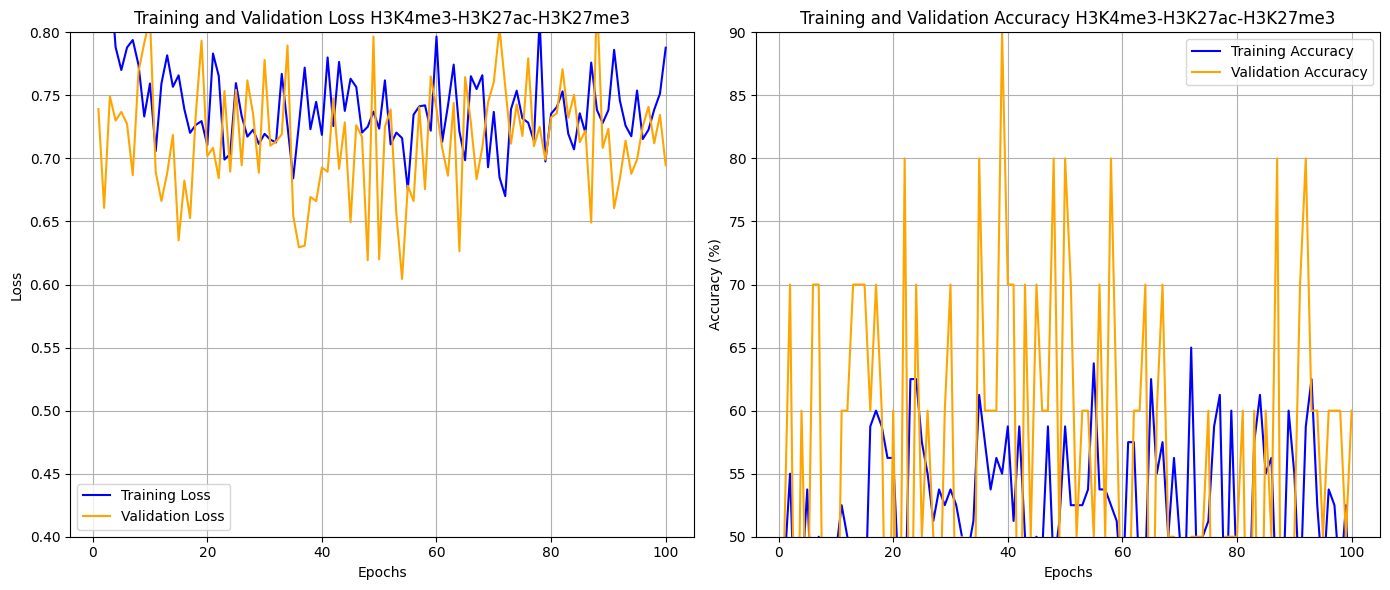

In [33]:
# Plot training and validation metric
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, item_name, NUM_ITEMS, IMAGE_FILE)

In [34]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [35]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [41]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 60.00 %
AUC Score on test set: 0.43
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75         7
           1       0.00      0.00      0.00         3

    accuracy                           0.60        10
   macro avg       0.33      0.43      0.38        10
weighted avg       0.47      0.60      0.53        10


Confusion Matrix:
[[6 1]
 [3 0]]



In [42]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [43]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [44]:
# Get the average for each column
experiment_mean = experiment_pl.mean()
experiment_mean

train_loss,train_accuracy,train_auc,val_loss,val_accuracy,val_auc
f64,f64,f64,f64,f64,f64
0.741681,52.4,0.5083,0.713862,54.9,0.515


In [45]:
# Test output
test_results = {
    'histone_marker'     : item_name,
    'train_loss_avg'     : round(experiment_mean["train_loss"][0], 4),
    'train_accuracy_avg' : round(experiment_mean["train_accuracy"][0], 4),
    'train_auc_avg'      : round(experiment_mean["train_auc"][0], 4),
    'val_loss_avg'       : round(experiment_mean["val_loss"][0], 4),
    'val_accuracy_avg'   : round(experiment_mean["val_accuracy"][0], 4),
    'val_auc'            : round(experiment_mean["val_auc"][0], 4),
    'test_acc'           : round(test_acc_score, 4),
    'test_auc'           : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

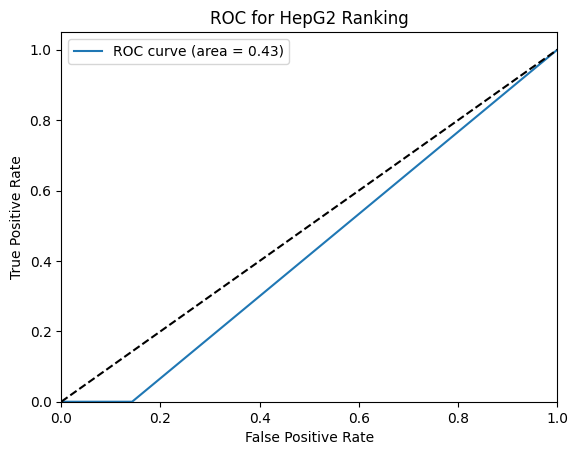

In [46]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

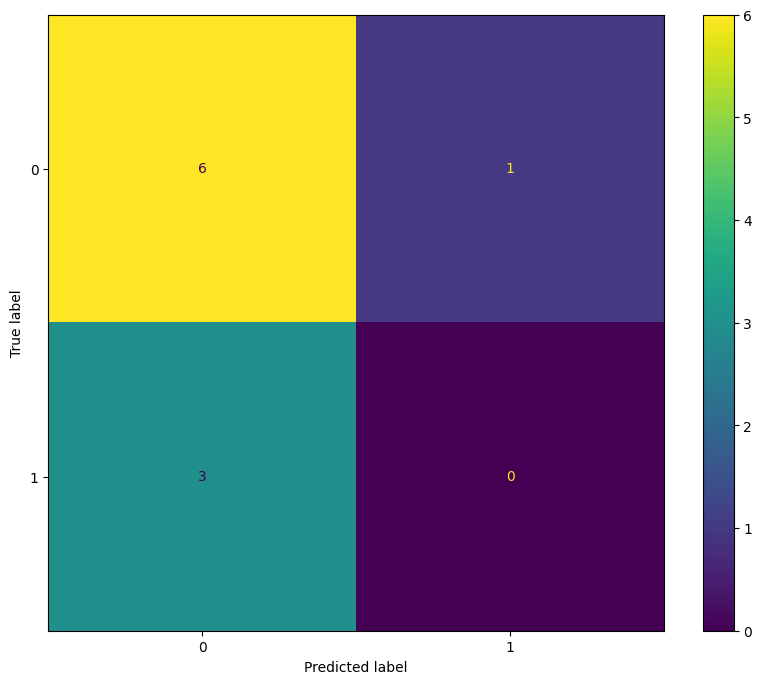

In [47]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)